In [16]:
import numpy as np
from w2v_utils import *

In [17]:
def cosine_similarity(v, u):
    norm_v = np.sqrt(np.sum(v * v)) # or np.linalg.norm(v)
    norm_u = np.sqrt(np.sum(u * u))
    return np.dot(v, u) / (norm_v * norm_u)

In [18]:
words, word_to_vec_map = read_glove_vecs('data/glove.6B.50d.txt')

In [19]:
# Compute cosine similarity between word vectors to measure semantic similarity.
# - Similar words (father, mother) should have high similarity.
# - Unrelated words (ball, crocodile) should have low similarity.
# - Word relationships can be tested using vector arithmetic (e.g., country - capital),
#   but the direction must be consistent; otherwise, similarity may become negative.
father = word_to_vec_map["father"]
mother = word_to_vec_map["mother"]
ball = word_to_vec_map["ball"]
crocodile = word_to_vec_map["crocodile"]
france = word_to_vec_map["france"]
italy = word_to_vec_map["italy"]
paris = word_to_vec_map["paris"]
rome = word_to_vec_map["rome"]
print("cosine_similarity(father, mother) = ", cosine_similarity(father, mother))
print("cosine_similarity(ball, crocodile) = ",cosine_similarity(ball, crocodile))
print("cosine_similarity(france - paris, rome - italy) = ",cosine_similarity(france - paris, rome - italy))


cosine_similarity(father, mother) =  0.8909038442893615
cosine_similarity(ball, crocodile) =  0.2743924626137942
cosine_similarity(france - paris, rome - italy) =  -0.6751479308174201


In [20]:
def complete_analogy(word_a, word_b, word_c, word_to_vec_map):
    """
    Performs the word analogy task as explained above: a is to b as c is to ____.

    Arguments:
    word_a -- a word, string
    word_b -- a word, string
    word_c -- a word, string
    word_to_vec_map -- dictionary mapping words to their corresponding vectors

    Returns:
    best_word -- the word such that v_b - v_a is close to v_best_word - v_c
    """
    # Convert words to lowercase
    word_a, word_b, word_c = word_a.lower(), word_b.lower(), word_c.lower()

    e_a, e_b, e_c = word_to_vec_map[word_a], word_to_vec_map[word_b], word_to_vec_map[word_c]

    words = word_to_vec_map.keys()
    max_cosine_sim = -100
    best_word = None

    input_words = set([word_a, word_b, word_c])
    for w in words:
        if w in input_words:
            continue

        cosine_sim = cosine_similarity(e_b - e_a, word_to_vec_map[w] - e_c)

        if cosine_sim > max_cosine_sim:
            max_cosine_sim = cosine_sim
            best_word = w
    return best_word

In [6]:
to_try = [('italy', 'italian', 'spain'), ('india', 'delhi', 'japan'), ('man', 'woman', 'boy'), ('small', 'smaller', 'large')]
for a, b, c in to_try:
    print(f"{a} -> {b} :: {c} -> {complete_analogy(a, b, c, word_to_vec_map)}")

italy -> italian :: spain -> spanish
india -> delhi :: japan -> tokyo
man -> woman :: boy -> girl
small -> smaller :: large -> larger


In [21]:
g = word_to_vec_map['woman'] - word_to_vec_map['man']
print(g)

[-0.087144    0.2182     -0.40986    -0.03922    -0.1032      0.94165
 -0.06042     0.32988     0.46144    -0.35962     0.31102    -0.86824
  0.96006     0.01073     0.24337     0.08193    -1.02722    -0.21122
  0.695044   -0.00222     0.29106     0.5053     -0.099454    0.40445
  0.30181     0.1355     -0.0606     -0.07131    -0.19245    -0.06115
 -0.3204      0.07165    -0.13337    -0.25068714 -0.14293    -0.224957
 -0.149       0.048882    0.12191    -0.27362    -0.165476   -0.20426
  0.54376    -0.271425   -0.10245    -0.32108     0.2516     -0.33455
 -0.04371     0.01258   ]


In [22]:
print ('List of names and their similarities with constructed vector:')

# girls and boys name
name_list = ['john', 'marie', 'sophie', 'ronaldo', 'priya', 'rahul', 'danielle', 'reza', 'katy', 'yasmin']

for w in name_list:
    print (w, cosine_similarity(word_to_vec_map[w], g))

List of names and their similarities with constructed vector:
john -0.23163356145973724
marie 0.315597935396073
sophie 0.31868789859418784
ronaldo -0.31244796850329437
priya 0.17632041839009402
rahul -0.16915471039231716
danielle 0.24393299216283895
reza -0.07930429672199553
katy 0.2831068659572615
yasmin 0.23313857767928758


In [23]:
print('Other words and their similarities:')
word_list = ['lipstick', 'guns', 'science', 'arts', 'literature', 'warrior','doctor', 'tree', 'receptionist', 
             'technology',  'fashion', 'teacher', 'engineer', 'pilot', 'computer', 'singer', "mohammad", "sara", "michael", "lisa"]
for w in word_list:
    print (w, cosine_similarity(word_to_vec_map[w], g))

Other words and their similarities:
lipstick 0.2769191625638267
guns -0.1888485567898898
science -0.06082906540929701
arts 0.008189312385880337
literature 0.06472504433459932
warrior -0.20920164641125288
doctor 0.11895289410935041
tree -0.07089399175478091
receptionist 0.33077941750593737
technology -0.13193732447554302
fashion 0.03563894625772699
teacher 0.17920923431825664
engineer -0.0803928049452407
pilot 0.0010764498991916937
computer -0.10330358873850498
singer 0.1850051813649629
mohammad -0.2949762041874635
sara 0.22726941741882256
michael -0.2875842339815393
lisa 0.2668804106853904


# Neutralize

Neutralize removes the bias component from a word vector by projecting it onto the space orthogonal to the bias axis. This ensures that gender-neutral words have zero projection on the gender subspace.

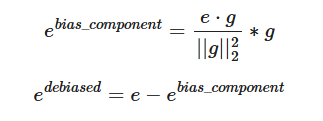

In [11]:
def neutralize(word, g, word_to_vec_map):
    """
    Removes the bias of "word" by projecting it on the space orthogonal to the bias axis. 
    This function ensures that gender neutral words are zero in the gender subspace.
    
    Arguments:
        word -- string indicating the word to debias
        g -- numpy-array of shape (50,), corresponding to the bias axis (such as gender)
        word_to_vec_map -- dictionary mapping words to their corresponding vectors.
    
    Returns:
        e_debiased -- neutralized word vector representation of the input "word"
    """
    
    # Select word vector representation of "word"
    e = word_to_vec_map[word]
    
    # Compute e_biascomponent  
    e_biascomponent = np.dot(e ,g) / np.sum(g * g) * g
 
    # Neutralize e by substracting e_biascomponent from it 
    # e_debiased should be equal to its orthogonal projection
    e_debiased = e - e_biascomponent
    
    return e_debiased

In [12]:
e = "receptionist"
print("cosine similarity between " + e + " and g, before neutralizing: ", cosine_similarity(word_to_vec_map["receptionist"], g))

e_debiased = neutralize("receptionist", g, word_to_vec_map)
print("cosine similarity between " + e + " and g, after neutralizing: ", cosine_similarity(e_debiased, g))

cosine similarity between receptionist and g, before neutralizing:  0.33077941750593737
cosine similarity between receptionist and g, after neutralizing:  -2.6899228119517285e-17


# Equalization

Equalization adjusts pairs of gender-specific words (e.g., "he" and "she") so that they are equidistant from the bias axis. This balances the representations to reduce bias while preserving the intended meanings.

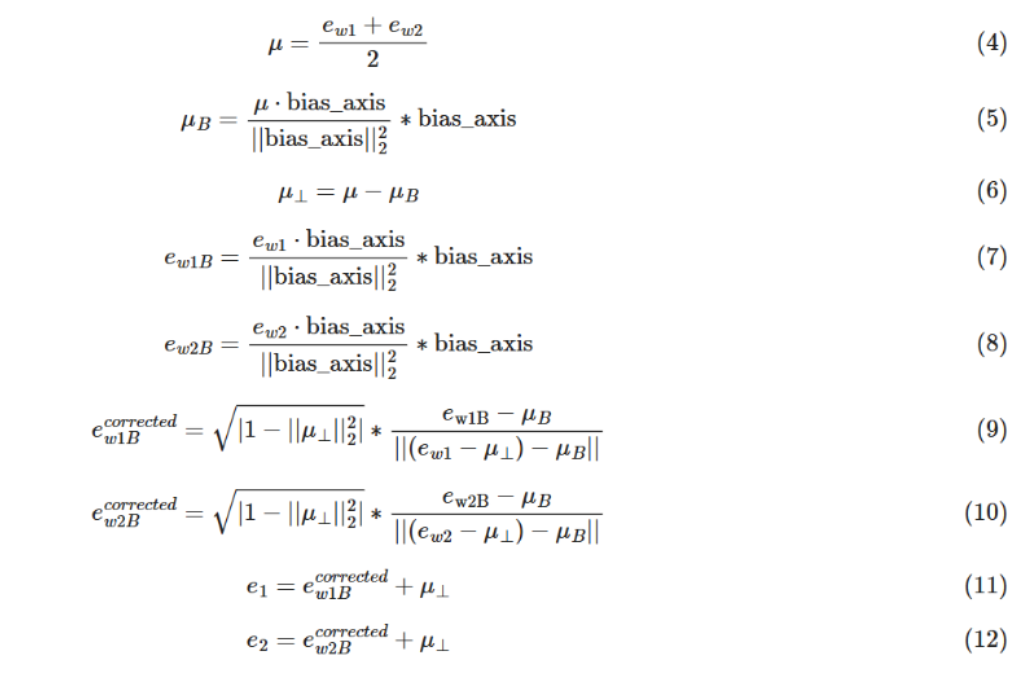
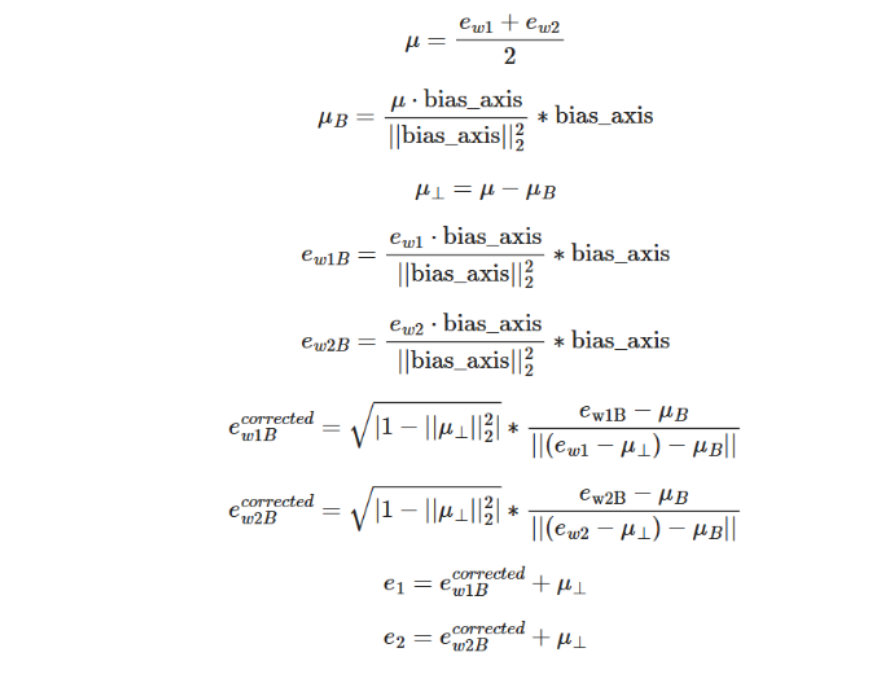

In [13]:
def equalize(pair, bias_axis, word_to_vec_map):
    """
    Debias gender specific words by following the equalize method .
    
    Arguments:
    pair -- pair of strings of gender specific words to debias, e.g. ("actress", "actor") 
    bias_axis -- numpy-array of shape (50,), vector corresponding to the bias axis, e.g. gender
    word_to_vec_map -- dictionary mapping words to their corresponding vectors
    
    Returns
    e_1 -- word vector corresponding to the first word
    e_2 -- word vector corresponding to the second word
    """
    
    # Select word vector representation of "word" 
    w1, w2 = pair
    e_w1, e_w2 = word_to_vec_map[w1],word_to_vec_map[w2]
    
    # Compute the mean of e_w1 and e_w2 
    mu = (e_w1 + e_w2) / 2

    # Compute the projections of mu over the bias axis and the orthogonal axis 
    mu_B = np.dot(mu, bias_axis) / np.sum(bias_axis * bias_axis) * bias_axis
    mu_orth = mu - mu_B

    # Use equations (7) and (8) to compute e_w1B and e_w2B 
    e_w1B = np.dot(e_w1, bias_axis) / np.sum(bias_axis * bias_axis) * bias_axis
    e_w2B = np.dot(e_w2, bias_axis) / np.sum(bias_axis * bias_axis) * bias_axis
        
    # Adjust the Bias part of e_w1B and e_w2B using the formulas (9) and (10) 
    corrected_e_w1B = np.sqrt(np.abs(1 - np.sum(mu_orth * mu_orth))) * (e_w1B - mu_B) / np.linalg.norm(e_w1 - mu_orth - mu_B)
    corrected_e_w2B = np.sqrt(np.abs(1 - np.sum(mu_orth * mu_orth))) * (e_w2B - mu_B) / np.linalg.norm(e_w2 - mu_orth - mu_B)

    # Debias by equalizing e1 and e2 to the sum of their corrected projections 
    e1 = corrected_e_w1B + mu_orth
    e2 = corrected_e_w2B + mu_orth
                                                                

    return e1, e2

In [15]:
print("cosine similarities before equalizing:")
print("cosine_similarity(man, gender) = ", cosine_similarity(word_to_vec_map["man"], g))
print("cosine_similarity(woman, gender) = ", cosine_similarity(word_to_vec_map["woman"], g))
print()
e1, e2 = equalize(("man", "woman"), g, word_to_vec_map)
print("cosine similarities after equalizing:")
print("cosine_similarity(e1, gender) = ", cosine_similarity(e1, g))
print("cosine_similarity(e2, gender) = ", cosine_similarity(e2, g))

cosine similarities before equalizing:
cosine_similarity(man, gender) =  -0.11711095765336832
cosine_similarity(woman, gender) =  0.35666618846270376

cosine similarities after equalizing:
cosine_similarity(e1, gender) =  -0.7004364289309387
cosine_similarity(e2, gender) =  0.7004364289309387
